# Exercise 1

In [1]:
import matplotlib.pyplot as plt

# Plotting style
import seaborn as sns
sns.set_style('darkgrid')
sns.set_theme(font_scale=1.)

import pandas as pd
import numpy as np
import statsmodels.api as sm

### 0) Indlæser data

In [2]:
df = pd.read_csv("Caschool.csv")

# Displaying the dataframe.
display(df.head())

,Unnamed: 0,distcod,county,district,grspan,enrltot,teachers,calwpct,mealpct,computer,testscr,compstu,expnstu,str,avginc,elpct,readscr,mathscr
0,1,75119,Alameda,Sunol Glen Unified,KK-08,195,10.900000,0.510200,2.040800,67,690.799988,0.343590,6384.911133,17.889910,22.690001,0.000000,691.599976,690.000000
1,2,61499,Butte,Manzanita Elementary,KK-08,240,11.150000,15.416700,47.916698,101,661.200012,0.420833,5099.380859,21.524664,9.824000,4.583333,660.500000,661.900024
2,3,61549,Butte,Thermalito Union Elementary,KK-08,1550,82.900002,55.032299,76.322601,169,643.599976,0.109032,5501.954590,18.697226,8.978000,30.000002,636.299988,650.900024
3,4,61457,Butte,Golden Feather Union Elementary,KK-08,243,14.000000,36.475399,77.049202,85,647.700012,0.349794,7101.831055,17.357143,8.978000,0.000000,651.900024,643.500000
4,5,61523,Butte,Palermo Union Elementary,KK-08,1335,71.500000,33.108601,78.427002,171,640.849976,0.128090,5235.987793,18.671329,9.080333,13.857677,641.799988,639.900024


In [3]:
# Sortere for san Diego County og laver sin egen data frame
df_sandiego = df.loc[df['county'] == 'San Diego']

# Fjerner Fra den oprindelige data frame 
df = df[df['county'] != 'San Diego']

df_sandiego.head()

,Unnamed: 0,distcod,county,district,grspan,enrltot,teachers,calwpct,mealpct,computer,testscr,compstu,expnstu,str,avginc,elpct,readscr,mathscr
30,31,68379,San Diego,San Ysidro Elementary,KK-08,4142,201.000000,35.562500,81.506500,569,624.550049,0.137373,5342.233398,20.606966,6.61300,80.420090,620.400024,628.700012
68,69,68221,San Diego,National Elementary,KK-06,6639,304.730011,26.841400,100.000000,505,634.099976,0.076066,5339.391113,21.786499,8.42300,58.081036,631.500000,636.700012
117,118,68395,San Diego,South Bay Union Elementary,KK-06,10218,508.750000,17.420200,70.806396,1435,641.449951,0.140438,5518.702148,20.084520,10.60247,41.133293,638.599976,644.299988
145,146,68205,San Diego,Lemon Grove Elementary,KK-08,4612,232.970001,17.476101,65.915001,601,645.550049,0.130312,5124.836426,19.796539,12.82700,16.652212,647.700012,643.400024
159,160,68023,San Diego,Chula Vista Elementary,KK-06,21338,1051.579956,13.227200,45.994999,2889,647.250000,0.135392,5123.474121,20.291372,14.29830,34.337799,645.000000,649.500000


### a) Descriptive statistics

Kan udvides når vi ved hvilke parametre vi vælger i modellen

In [7]:
df.describe()

,Unnamed: 0,distcod,enrltot,teachers,calwpct,mealpct,computer,testscr,compstu,expnstu,str,avginc,elpct,readscr,mathscr
count,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000
mean,208.283208,67435.819549,2442.398496,120.053729,13.403622,44.937275,281.045113,653.826692,0.136249,5307.119603,19.631369,15.204403,15.429893,654.734337,652.919047
std,121.607687,3553.254403,3625.064169,173.749079,11.559538,27.187718,396.202854,19.089171,0.065405,644.263914,1.901437,7.235224,18.127411,20.186765,18.755678
min,1.000000,61382.000000,81.000000,4.850000,0.000000,0.000000,0.000000,605.550049,0.000000,3926.069580,14.000000,5.335000,0.000000,604.500000,605.400024
25%,102.500000,64084.000000,362.000000,18.900000,4.469800,23.541451,46.000000,639.774994,0.092863,4893.213135,18.585708,10.634000,1.780019,640.250000,638.700012
50%,208.000000,67405.000000,888.000000,46.660000,10.593200,42.446800,114.000000,654.199951,0.124060,5211.485352,19.643900,13.630000,8.662933,655.400024,651.900024
75%,310.500000,70619.000000,2804.000000,139.790001,19.307400,66.927853,327.000000,666.299988,0.167880,5596.902100,20.849567,17.507999,22.781713,668.600006,665.400024
max,420.000000,75440.000000,27176.000000,1429.000000,78.994202,100.000000,3324.000000,706.750000,0.420833,7711.506836,25.799999,55.327999,85.539719,704.000000,709.500000


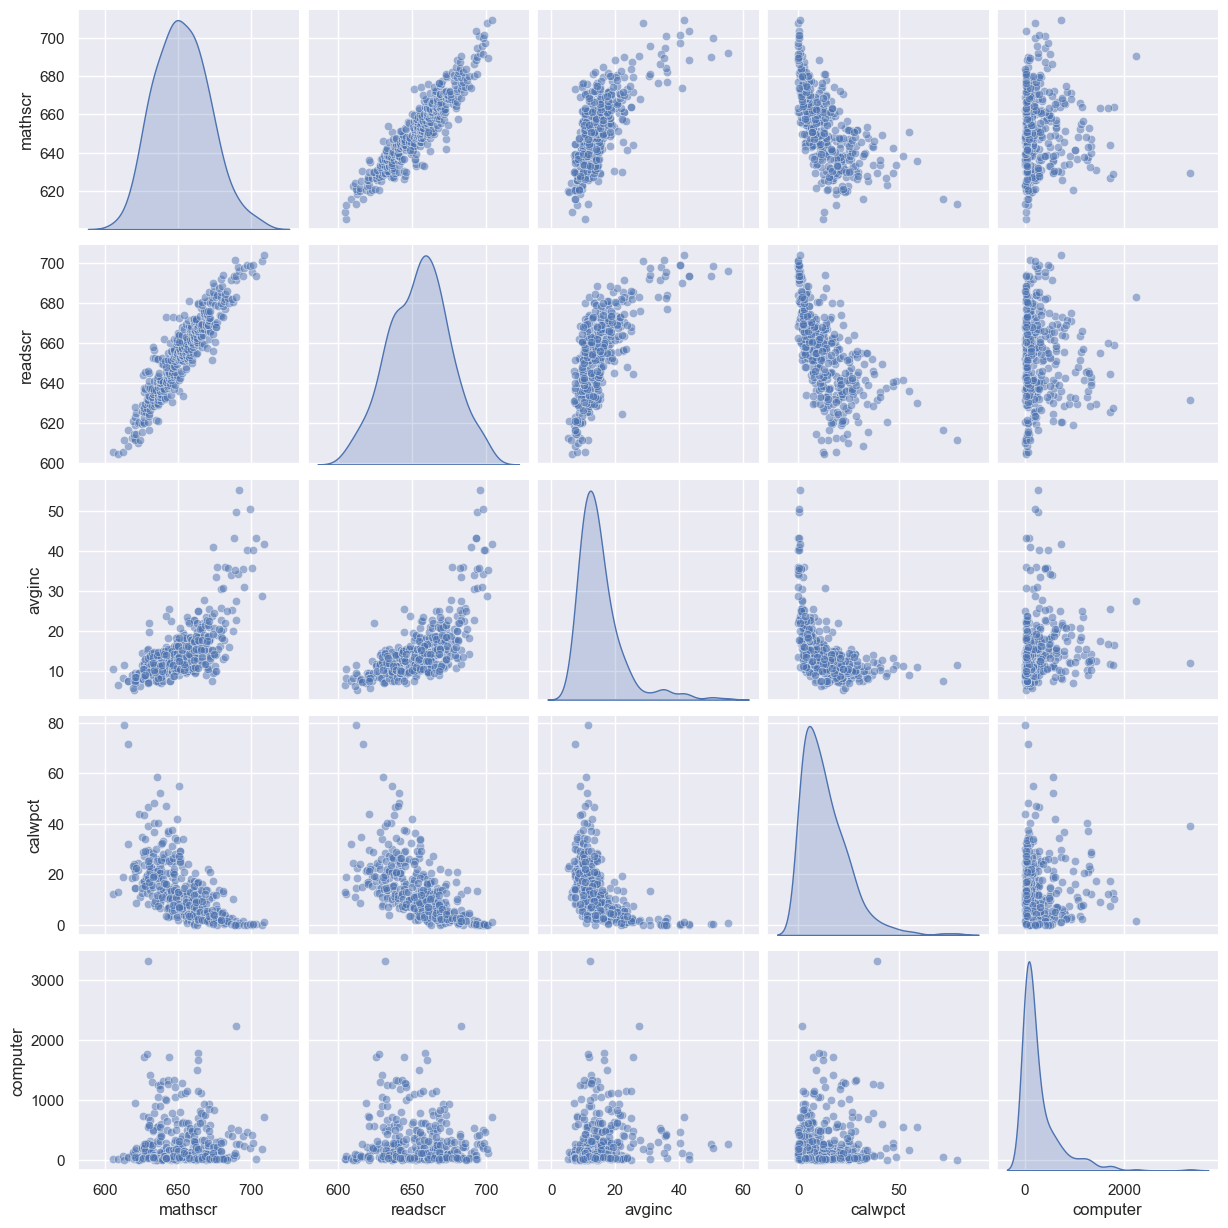

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Vælg de kolonner du vil kigge på
cols = ['mathscr', 'readscr', 'avginc', 'calwpct', 'computer']

# Lav et pairplot
sns.pairplot(df[cols], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.show()

### b) Linear regression model

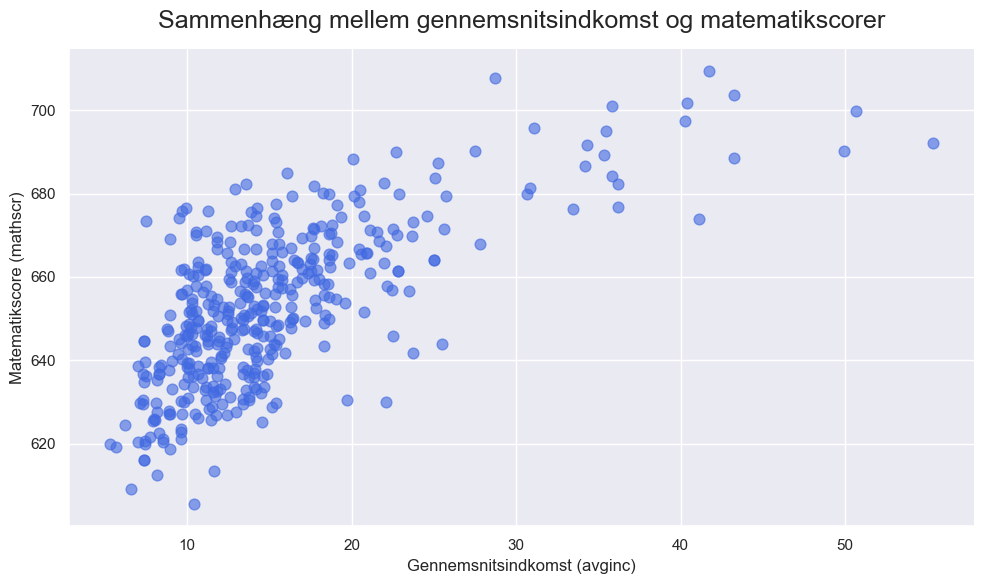

In [9]:
#Scatter plot over indkomst og matematikscorer, kan vise om sammenhængen er lineær eller andre faktorer der har betydning
#Kunne tyde på en log sammenhæng

plt.figure(figsize=(10, 6))

plt.scatter(
    x=df['avginc'], 
    y=df['mathscr'], 
    alpha=0.6,          
    c='royalblue',      
    s=60              
)

# 4. Tilføj titler og labels
plt.title('Sammenhæng mellem gennemsnitsindkomst og matematikscorer', fontsize=18, pad=15)
plt.xlabel('Gennemsnitsindkomst (avginc)', fontsize=12)
plt.ylabel('Matematikscore (mathscr)', fontsize=12)

sns.despine()

plt.tight_layout()
plt.show()

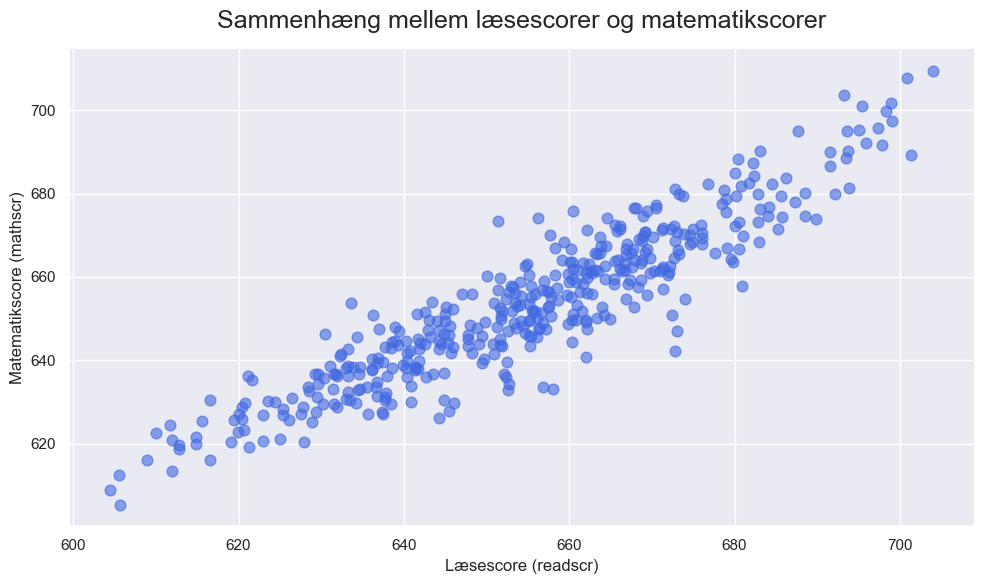

In [41]:
#Scatter plot over indkomst og matematikscorer, kan vise om sammenhængen er lineær eller andre faktorer der har betydning
#Kunne tyde på en log sammenhæng

plt.figure(figsize=(10, 6))

plt.scatter(
    x=df['readscr'], 
    y=df['mathscr'], 
    alpha=0.6,          
    c='royalblue',      
    s=60              
)

# 4. Tilføj titler og labels
plt.title('Sammenhæng mellem læsescorer og matematikscorer', fontsize=18, pad=15)
plt.xlabel('Læsescore (readscr)', fontsize=12)
plt.ylabel('Matematikscore (mathscr)', fontsize=12)

sns.despine()

plt.tight_layout()
plt.show()

In [ ]:
# 1. model: indkomst forklarer matematikscorer 

# Specify data
Y = df[["mathscr"]]
Xs = df[["avginc"]]

# Add a constant term to the predictor
X = sm.add_constant(Xs)

# Define linear regression model
model = sm.OLS(Y, X, missing="drop")
result = model.fit()
print(result.summary(slim=True))

                            OLS Regression Results                            
Dep. Variable:                mathscr   R-squared:                       0.489
Model:                            OLS   Adj. R-squared:                  0.488
No. Observations:                 420   F-statistic:                     400.3
Covariance Type:            nonrobust   Prob (F-statistic):           5.99e-63
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        625.5395      1.536    407.182      0.000     622.520     628.559
avginc         1.8152      0.091     20.006      0.000       1.637       1.994

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.


In [46]:
# 2. model: logtransformation af indkomst forklarer matematikscorer 

df['log_avginc'] = np.log(df['avginc'])

# Specify data
Y = df[["mathscr"]]
Xs = df[["log_avginc"]]

# Add a constant term to the predictor
X = sm.add_constant(Xs)

# Define linear regression model
model = sm.OLS(Y, X, missing="drop")
result = model.fit()
print(result.summary(slim=True))

                            OLS Regression Results                            
Dep. Variable:                mathscr   R-squared:                       0.526
Model:                            OLS   Adj. R-squared:                  0.525
No. Observations:                 420   F-statistic:                     463.8
Covariance Type:            nonrobust   Prob (F-statistic):           9.39e-70
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        561.6613      4.304    130.511      0.000     553.202     570.121
log_avginc    34.6642      1.610     21.536      0.000      31.500      37.828

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.


Variabel indkomst i 1. model er signifikant med en p-værdi < 0,05. 

Overvejer hvilke variable der kunne have en betydning på math score: 
1. Calworks: Procentdel der kvalificere sig til CalWorks (income assistance). Angiver hvor stor en del fra skolens område der er fattige under en vis grænse? 
2. Elever pr. lærer: Ny variabel der forklare hvor mange lærer der er pr elev. Kan have indvirkning hvor meget tid hver elev har med lærer alene
3. Read: Hvis man er god til at læse, kan det være man også er god til matematik

Tester en efter en om variablen er signifikant og om det øjer adj. $R^2$

In [ ]:
# 2. model: indkomst og elever pr lærer forklarer matematikscorer 

#Danner ny variabel antal elever pr lærer
df['elevprlærer'] = df['enrltot']/df['teachers']

Y = df[["mathscr"]]
Xs = df[["avginc",'elevprlærer']]

# Add a constant term to the predictor
X = sm.add_constant(Xs)

# Define linear regression model
model = sm.OLS(Y, X, missing="drop")
result = model.fit()
print(result.summary(slim=True))

                            OLS Regression Results                            
Dep. Variable:                mathscr   R-squared:                       0.490
Model:                            OLS   Adj. R-squared:                  0.488
No. Observations:                 420   F-statistic:                     200.6
Covariance Type:            nonrobust   Prob (F-statistic):           9.37e-62
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         632.6867      7.489     84.479      0.000     617.965     647.408
avginc          1.7941      0.093     19.232      0.000       1.611       1.977
elevprlærer    -0.3474      0.356     -0.975      0.330      -1.048       0.353

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.


- I 2. model er elevprlærer ikke signifikant da p-værdien er markant højere end 0,05. Derfor fjernes den igen? 
- Tester ny model med variablen Calworks i procent

In [35]:
# 2. model: indkomst og calworks forklarer matematikscorer 

Y = df[["mathscr"]]
Xs = df[["avginc",'readscr']]

# Add a constant term to the predictor
X = sm.add_constant(Xs)

# Define linear regression model
model = sm.OLS(Y, X, missing="drop")
result = model.fit()
print(result.summary(slim=True))

                            OLS Regression Results                            
Dep. Variable:                mathscr   R-squared:                       0.858
Model:                            OLS   Adj. R-squared:                  0.857
No. Observations:                 420   F-statistic:                     1257.
Covariance Type:            nonrobust   Prob (F-statistic):          2.67e-177
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        131.2887     15.060      8.718      0.000     101.686     160.891
avginc         0.2802      0.067      4.186      0.000       0.149       0.412
readscr        0.7905      0.024     32.867      0.000       0.743       0.838

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.85e+04. This might indicate that there are
strong multicollinearity or ot

- I model 3 er begge variable indkomst og Calworks er signifikante. 

In [49]:
# 3. model: indkomst, calworks og computer forklarer matematikscorer 

Y = df[["mathscr"]]
Xs = df[["avginc",'calwpct', 'readscr', 'expnstu']]

# Add a constant term to the predictor
X = sm.add_constant(Xs)

# Define linear regression model
model_log = sm.OLS(Y, X, missing="drop")
result = model_log.fit()
print(result.summary(slim=True))

                            OLS Regression Results                            
Dep. Variable:                mathscr   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.862
No. Observations:                 420   F-statistic:                     656.9
Covariance Type:            nonrobust   Prob (F-statistic):          5.34e-178
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        156.2998     16.660      9.382      0.000     123.552     189.048
avginc         0.3062      0.069      4.416      0.000       0.170       0.442
calwpct       -0.0817      0.040     -2.049      0.041      -0.160      -0.003
readscr        0.7673      0.026     29.347      0.000       0.716       0.819
expnstu       -0.0017      0.001     -2.890      0.004      -0.003      -0.001

Notes:
[1] Standard Errors assume that the covarian

Dilemma: 
- Vi skal argumentere for at ingen af de variable korrelere med hinanden. 

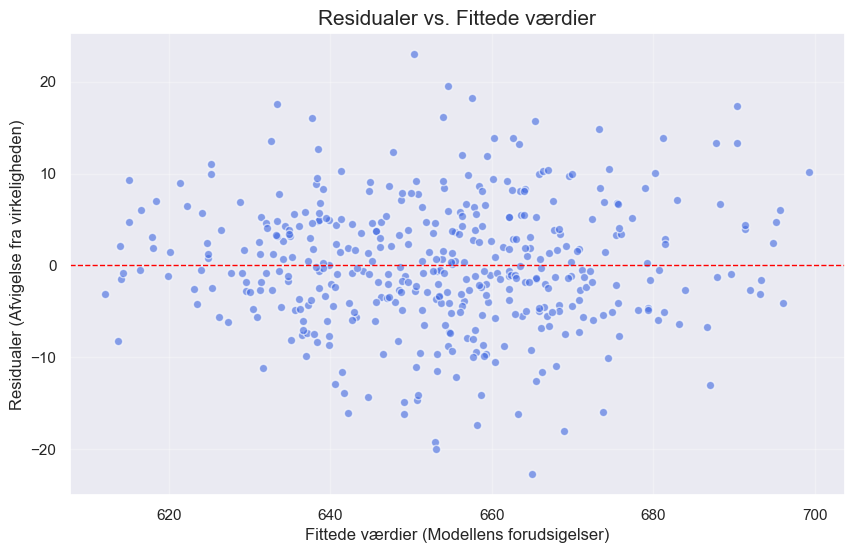

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Hent fittede værdier og residualer fra din model
# (Her antager jeg at din model hedder 'model_log' eller lignende)
fitted_vals = result.fittedvalues
residuals = result.resid

# 2. Lav plottet
plt.figure(figsize=(10, 6))
plt.scatter(x=fitted_vals, y=residuals, alpha=0.6, color='royalblue', edgecolors='w')

# 3. Tilføj en horisontal linje i 0 (den perfekte model har alle prikker på denne linje)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)

# 4. Labels og styling
plt.title('Residualer vs. Fittede værdier', fontsize=15)
plt.xlabel('Fittede værdier (Modellens forudsigelser)', fontsize=12)
plt.ylabel('Residualer (Afvigelse fra virkeligheden)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

Tanker om residualplottet: 
- Ingen tydelig bue, hvilket tyder på den lineær sammenhæng 
- Ingen outliers: ødelægger ikke modellen 
- Residualer fordeler sig pænt rundt om 0 

In [ ]:
Test test